In [1]:
from pathlib import Path
import inspect
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd()

for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "obscalib").exists():
        ROOT = candidate
        break

if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from kaist_dataset.dataset import KAISTCalibrationDataset, build_kaist_sequence_specs

from obscalib.calibration.state import CalibrationState
from obscalib.calibration.update import CalibrationUpdater
from obscalib.data.collation import collate_windows
from obscalib.data.device import window_batch_to
from obscalib.geometry.lie import se3_exp, se3_log
from obscalib.geometry.processing import GeometryProcessor
from obscalib.models.obs_calib_model import ObsCalibModel
from obscalib.observability.estimators import ObservabilityMatrixEstimator
from obscalib.observability.layout import CalibrationParameterLayout
from obscalib.observability.mappings import CRLBTanhObservabilityMapper, CombinedObservabilityMapper, FlattenObservabilityMapper, LogConditionObservabilityMapper, SoftRankObservabilityMapper
from obscalib.observability.numerics import ObservabilityNumericsConfig
from obscalib.pipeline.window_step import WindowStep
from obscalib.tokenization.tokenizer import Tokenizer
from obscalib.training.checkpoint import load_training_checkpoint, read_training_checkpoint

In [2]:
##################################################
# Checkpoint
##################################################

RUN_NAME = "kaist_observability_crlb_tanh_001"
CHECKPOINT_PATH = ROOT / "runs" / RUN_NAME / "best.pt"

##################################################
# Compute device
##################################################

DEVICE_NAME = "cuda"
DEVICE = torch.device(DEVICE_NAME)
MODEL_DTYPE = torch.float32

##################################################
# Dataset location
##################################################

KAIST_DATASET_ROOT = Path("/mnt/d/Downloads/MobRobLab/KAISTDataset")
LIDAR_POSE_ROOT = Path("/home/camel/Skoltech/phd_proposal/data/KAISTDataset")

##################################################
# Rollout sequence
##################################################

SEQUENCE_NAME = "Urban38"
ROLLOUT_START_WINDOW = 0
ROLLOUT_NUM_WINDOWS = None
RUN_PREFLIGHT = True

##################################################
# Initial calibration error
##################################################
#
# delta_xi follows [phi_x, phi_y, phi_z, rho_x, rho_y, rho_z] and is applied with the same left perturbation used during training:
#
# T_initial = Exp(delta_xi) @ T_true
##################################################

INITIAL_DELTA_XI = {"imu": np.array([np.deg2rad(8.0), np.deg2rad(-6.0), np.deg2rad(5.0), 0.08, -0.05, 0.04]), "lidar": np.array([np.deg2rad(-8.0), np.deg2rad(6.0), np.deg2rad(-5.0), -0.08, 0.05, -0.04])}
INITIAL_DELTA_TAU_S = {"imu": 0.020, "lidar": -0.020}

In [3]:
checkpoint_data = read_training_checkpoint(CHECKPOINT_PATH, map_location="cpu")
experiment = checkpoint_data.get("extra_state", {}).get("experiment")

if experiment is None:
    raise ValueError("This checkpoint does not contain an experiment snapshot. Use a checkpoint produced by the observability-enabled training notebook.")

if "observability_config" not in experiment:
    raise ValueError("This checkpoint does not contain observability_config. Use a checkpoint produced by the observability-enabled training notebook.")

model_config = experiment["model_config"]
windowing_config = experiment["windowing_config"]
rig_calibration = experiment["rig_calibration"]
measurement_dim = experiment["measurement_dim"]
observability_config = experiment["observability_config"]

OBSERVABILITY_MODE = observability_config["mode"]
OBSERVABILITY_COMPONENT_ORDER = tuple(observability_config.get("component_order", (OBSERVABILITY_MODE,)))
OBSERVABILITY_FEATURE_DIM = int(observability_config["feature_dim"])
USE_NJIT_OBSERVABILITY = bool(observability_config.get("use_njit", True))
PROJECTION_NUMERICAL_TOLERANCE = float(observability_config["projection_numerical_tolerance"])
CRLB_OBSERVABILITY_TOLERANCE = float(observability_config["crlb_observability_tolerance"])
COORDINATE_NULLSPACE_TOLERANCE = float(observability_config["coordinate_nullspace_tolerance"])
CRLB_TANH_ROTATION_ALPHA_RAD = float(observability_config["crlb_rotation_alpha_rad"])
CRLB_TANH_TRANSLATION_ALPHA_M = float(observability_config["crlb_translation_alpha_m"])
CRLB_TANH_TIME_ALPHA_S = float(observability_config["crlb_time_alpha_s"])
SOFT_RANK_THRESHOLD = float(observability_config.get("soft_rank_threshold", 1e-5))
SOFT_RANK_TEMPERATURE = float(observability_config.get("soft_rank_temperature", 2e-6))
REFERENCE_LIDAR_STREAM_KEY = observability_config.get("reference_lidar_stream_key", "lidar")

if OBSERVABILITY_MODE == "none":
    raise ValueError("The selected checkpoint was trained without observability. This rollout notebook requires an observability-enabled checkpoint.")

CALIBRATION_KEYS = tuple(model_config.head_keys)
calibration_layout = CalibrationParameterLayout.from_calibration_keys(CALIBRATION_KEYS)
BASE_TOKEN_INPUT_DIM = measurement_dim + 2
EXPECTED_TOKEN_INPUT_DIM = BASE_TOKEN_INPUT_DIM + OBSERVABILITY_FEATURE_DIM

if model_config.transformer.input_dim != EXPECTED_TOKEN_INPUT_DIM:
    raise ValueError(f"Checkpoint token input dimension mismatch: model expects {model_config.transformer.input_dim}, while measurement_dim={measurement_dim} and observability feature_dim={OBSERVABILITY_FEATURE_DIM} imply {EXPECTED_TOKEN_INPUT_DIM}.")

print("Checkpoint:", CHECKPOINT_PATH)
print("Checkpoint epoch:", checkpoint_data.get("epoch"))
print("Sequence split:", experiment["sequence_split"])
print("Observability mode:", OBSERVABILITY_MODE)
print("Observability component order:", OBSERVABILITY_COMPONENT_ORDER)
print("Calibration layout:", calibration_layout.calibration_keys)
print("Observability feature dimension:", OBSERVABILITY_FEATURE_DIM)
print("Transformer token input dimension:", model_config.transformer.input_dim)
print("NJIT observability:", USE_NJIT_OBSERVABILITY)
print()
print("Model configuration:")
print(model_config)
print()
print("Window configuration:")
print(windowing_config)

Checkpoint: /home/camel/Skoltech/Mobile_Robotics_Lab/nn-obs-calib/runs/kaist_observability_crlb_tanh_001/best.pt
Checkpoint epoch: 50
Sequence split: {'train': ('Urban08', 'Urban12', 'Urban13', 'Urban14', 'Urban15', 'Urban16'), 'validation': ('Urban26', 'Urban28'), 'test': ('Urban38', 'Urban39')}
Observability mode: crlb_tanh
Observability component order: ('crlb_tanh',)
Calibration layout: ('imu', 'lidar')
Observability feature dimension: 14
Transformer token input dimension: 22
NJIT observability: True

Model configuration:
ObsCalibModelConfig(transformer=TransformerConfig(input_dim=22, d_model=128, n_heads=8, num_layers=12, dim_feedforward=512, dropout=0.1, num_summary_tokens=4, activation='gelu'), mlp=MLPConfig(hidden_dims=(256, 128), output_dim=128, activation='gelu', dropout=0.1), calibration_head=CalibrationHeadConfig(calibration_context_dim=7, hidden_dims=(128, 64), activation='gelu', dropout=0.1), head_keys=('imu', 'lidar'))

Window configuration:
WindowingConfig(window_durati

In [4]:
sequence_split = experiment["sequence_split"]

if SEQUENCE_NAME in sequence_split["train"]:
    print(f"WARNING: {SEQUENCE_NAME} belongs to the training split.")
elif SEQUENCE_NAME in sequence_split["validation"]:
    print(f"{SEQUENCE_NAME} belongs to the validation split.")
elif SEQUENCE_NAME in sequence_split["test"]:
    print(f"{SEQUENCE_NAME} belongs to the held-out test split.")
else:
    print(f"{SEQUENCE_NAME} was not part of the recorded experiment split.")

Urban38 belongs to the held-out test split.


In [5]:
sequence_spec = build_kaist_sequence_specs(sequence_names=[SEQUENCE_NAME], kaist_dataset_root=KAIST_DATASET_ROOT, lidar_pose_root=LIDAR_POSE_ROOT)[0]
rollout_dataset = KAISTCalibrationDataset([sequence_spec], rig_calibration, windowing_config, measurement_dtype=torch.float32, source_timestamp_dtype=torch.float64, window_timestamp_dtype=torch.float32)

print(rollout_dataset.summary())

KAISTCalibrationDataset: 349 windows from 1 sequences
approximate tensor storage: 6.5 MiB
  Urban38: windows=349, duration=2147.3s, IMU=216225, LiDAR=17005


In [6]:
##################################################
# Network-facing observability mapper
##################################################

observability_numerics = ObservabilityNumericsConfig(relative_tolerance=PROJECTION_NUMERICAL_TOLERANCE, parameter_scales=None)
CRLB_TANH_ALPHA = (CRLB_TANH_ROTATION_ALPHA_RAD, CRLB_TANH_ROTATION_ALPHA_RAD, CRLB_TANH_ROTATION_ALPHA_RAD, CRLB_TANH_TRANSLATION_ALPHA_M, CRLB_TANH_TRANSLATION_ALPHA_M, CRLB_TANH_TRANSLATION_ALPHA_M, CRLB_TANH_TIME_ALPHA_S)

def observability_component_order() -> tuple[str, ...]:
    """Return the exact feature-component order used by the checkpoint."""
    if OBSERVABILITY_MODE == "combined":
        return OBSERVABILITY_COMPONENT_ORDER
    return (OBSERVABILITY_MODE,)

def build_observability_component_mapper(component: str):
    """Build one checkpoint-compatible observability feature mapper."""
    if component == "crlb_tanh":
        return CRLBTanhObservabilityMapper(alpha=CRLB_TANH_ALPHA, numerics=observability_numerics, relative_tolerance=CRLB_OBSERVABILITY_TOLERANCE, nullspace_tolerance=COORDINATE_NULLSPACE_TOLERANCE)
    if component == "matrix":
        return FlattenObservabilityMapper(numerics=observability_numerics)
    if component == "soft_rank":
        return SoftRankObservabilityMapper(threshold=SOFT_RANK_THRESHOLD, temperature=SOFT_RANK_TEMPERATURE, numerics=observability_numerics)
    if component == "log_condition":
        return LogConditionObservabilityMapper(numerics=observability_numerics)
    raise ValueError(f"Unknown observability component {component!r}.")

def build_observability_mapper():
    """Build the complete network-facing observability mapper."""
    component_mappers = [build_observability_component_mapper(component) for component in observability_component_order()]
    if len(component_mappers) == 1:
        return component_mappers[0]
    return CombinedObservabilityMapper(component_mappers)

observability_mapper = build_observability_mapper()

In [7]:
##################################################
# Empirical KAIST residual covariance
##################################################

GYRO_MEASUREMENT_COVARIANCE = torch.tensor([[2.96367932e-06, -1.94438078e-07, -4.83643437e-07], [-1.94438078e-07, 1.89162212e-06, 1.09062693e-07], [-4.83643437e-07, 1.09062693e-07, 1.88843506e-06]], dtype=torch.float64)
ACCEL_MEASUREMENT_COVARIANCE = torch.tensor([[4.85003041e-03, -9.25262862e-05, 2.14219676e-04], [-9.25262862e-05, 1.51980006e-03, -1.13182999e-03], [2.14219676e-04, -1.13182999e-03, 2.29777687e-03]], dtype=torch.float64)
LIDAR_SCAN_TO_MAP_ROTATION_COVARIANCE = torch.tensor([[1.10442767e-05, 9.46809587e-07, 3.78536515e-06], [9.46809587e-07, 3.35041997e-05, 1.90008728e-06], [3.78536515e-06, 1.90008728e-06, 1.10553483e-05]], dtype=torch.float64)
LIDAR_SCAN_TO_MAP_TRANSLATION_COVARIANCE = torch.tensor([[0.00843466, 0.00266052, 0.00702046], [0.00266052, 0.01444850, 0.00225705], [0.00702046, 0.00225705, 0.00704268]], dtype=torch.float64)
LIDAR_SCAN_TO_MAP_COVARIANCE = torch.zeros((6, 6), dtype=torch.float64)
LIDAR_SCAN_TO_MAP_COVARIANCE[:3, :3] = LIDAR_SCAN_TO_MAP_ROTATION_COVARIANCE
LIDAR_SCAN_TO_MAP_COVARIANCE[3:, 3:] = LIDAR_SCAN_TO_MAP_TRANSLATION_COVARIANCE
LIDAR_RELATIVE_RESIDUAL_COVARIANCE = 2.0 * LIDAR_SCAN_TO_MAP_COVARIANCE

residual_covariance_by_stream = {"gyro": GYRO_MEASUREMENT_COVARIANCE, "accel": ACCEL_MEASUREMENT_COVARIANCE, "lidar": LIDAR_RELATIVE_RESIDUAL_COVARIANCE}
GRAVITY_WORLD = torch.tensor([0.0, 0.0, 9.81], dtype=torch.float64)
gyro_bias_by_calibration_key = {"imu": torch.zeros(3, dtype=torch.float64)}

##################################################
# Local nominal trajectory used by observability
##################################################

def relative_lidar_body_trajectory_provider(measurements, metadata, calibration, reference_timebase):
    """Construct the same local LiDAR-derived body trajectory used by observability-enabled training."""
    stream_key = reference_timebase.stream_key

    if stream_key != REFERENCE_LIDAR_STREAM_KEY:
        raise ValueError(f"Expected reference stream {REFERENCE_LIDAR_STREAM_KEY!r}, received {stream_key!r}.")
    if stream_key not in measurements or stream_key not in metadata:
        raise KeyError(f"Missing reference LiDAR stream {stream_key!r}.")

    stream = measurements[stream_key]

    if stream.interval_start_timestamps is None:
        raise ValueError("Reference LiDAR stream must carry interval_start_timestamps.")

    calibration_key = metadata[stream_key].calibration_key
    T_B_L = calibration[calibration_key].transform

    if T_B_L.ndim == 3:
        if T_B_L.shape[0] != 1:
            raise ValueError("Unbatched trajectory provider expects one calibration state.")
        T_B_L = T_B_L[0]

    T_B_L = T_B_L.to(device="cpu", dtype=torch.float64)
    T_L_B = torch.linalg.inv(T_B_L)
    relative_lidar_poses = stream.values.to(device="cpu", dtype=torch.float64)
    interval_starts = stream.interval_start_timestamps.to(device="cpu", dtype=torch.float64)
    interval_ends = stream.timestamps.to(device="cpu", dtype=torch.float64)
    reference_timestamps = reference_timebase.timestamps.to(device="cpu", dtype=torch.float64)

    if relative_lidar_poses.shape[0] == 0:
        raise ValueError("Reference LiDAR stream is empty.")

    poses_by_time = {}
    current_pose = torch.eye(4, dtype=torch.float64)
    current_end_time = None

    for interval_index in range(relative_lidar_poses.shape[0]):
        start_time = float(interval_starts[interval_index].item())
        end_time = float(interval_ends[interval_index].item())

        if current_end_time is None or abs(start_time - current_end_time) > 1e-6:
            start_pose = current_pose
        else:
            start_pose = current_pose

        poses_by_time[start_time] = start_pose
        relative_body_motion = T_B_L @ relative_lidar_poses[interval_index] @ T_L_B
        current_pose = start_pose @ relative_body_motion
        poses_by_time[end_time] = current_pose
        current_end_time = end_time

    available_times = np.asarray(sorted(poses_by_time), dtype=float)
    trajectory_poses = []

    for timestamp in reference_timestamps:
        query_time = float(timestamp.item())
        nearest_index = int(np.argmin(np.abs(available_times - query_time)))
        nearest_time = float(available_times[nearest_index])

        if abs(nearest_time - query_time) > 1e-6:
            raise ValueError(f"Could not construct nominal pose at reference timestamp {query_time:.9f}; nearest available LiDAR endpoint is {nearest_time:.9f}.")

        trajectory_poses.append(poses_by_time[nearest_time])

    return torch.stack(trajectory_poses, dim=0)

In [8]:
##################################################
# Scientific observability estimator
##################################################

estimator_signature = inspect.signature(ObservabilityMatrixEstimator.__init__)
estimator_kwargs = {"calibration_layout": calibration_layout, "trajectory_provider": relative_lidar_body_trajectory_provider, "residual_covariance_by_stream": residual_covariance_by_stream}
optional_estimator_kwargs = {"gravity_world": GRAVITY_WORLD, "gyro_bias_by_calibration_key": gyro_bias_by_calibration_key, "numerics": observability_numerics, "njit": USE_NJIT_OBSERVABILITY, "reference_stream_key": REFERENCE_LIDAR_STREAM_KEY}

for argument_name, argument_value in optional_estimator_kwargs.items():
    if argument_name in estimator_signature.parameters:
        estimator_kwargs[argument_name] = argument_value

missing_required_arguments = [name for name, parameter in estimator_signature.parameters.items() if name != "self" and parameter.kind in {inspect.Parameter.POSITIONAL_ONLY, inspect.Parameter.POSITIONAL_OR_KEYWORD, inspect.Parameter.KEYWORD_ONLY} and parameter.default is inspect.Parameter.empty and name not in estimator_kwargs]

if missing_required_arguments:
    raise RuntimeError(f"The installed ObservabilityMatrixEstimator has required constructor arguments not configured by this notebook: {missing_required_arguments}. Current signature: {estimator_signature}")

observability_estimator = ObservabilityMatrixEstimator(**estimator_kwargs)

print("Observability estimator:", observability_estimator.__class__.__name__)
print("Observability mapper:", observability_mapper.__class__.__name__)
print("Scientific calibration dimension:", calibration_layout.total_dimension)
print("Network observability feature dimension:", OBSERVABILITY_FEATURE_DIM)

Observability estimator: ObservabilityMatrixEstimator
Observability mapper: CRLBTanhObservabilityMapper
Scientific calibration dimension: 14
Network observability feature dimension: 14


In [9]:
##################################################
# Model and sequential WindowStep
##################################################

model = ObsCalibModel(model_config).to(device=DEVICE, dtype=MODEL_DTYPE)
load_training_checkpoint(CHECKPOINT_PATH, model=model, map_location=DEVICE, restore_rng_state=False)
model.eval()

geometry_processor = GeometryProcessor()
tokenizer = Tokenizer(measurement_dim=measurement_dim)
calibration_updater = CalibrationUpdater()
window_step = WindowStep(geometry_processor=geometry_processor, tokenizer=tokenizer, model=model, calibration_updater=calibration_updater, observability_estimator=observability_estimator, observability_mapper=observability_mapper)

print("Parameters:", sum(parameter.numel() for parameter in model.parameters()))
print("WindowStep observability enabled:", window_step.observability_estimator is not None and window_step.observability_mapper is not None)

Parameters: 2615954
WindowStep observability enabled: True


In [10]:
num_available_windows = len(rollout_dataset)
rollout_end_window = num_available_windows if ROLLOUT_NUM_WINDOWS is None else min(ROLLOUT_START_WINDOW + ROLLOUT_NUM_WINDOWS, num_available_windows)
rollout_indices = list(range(ROLLOUT_START_WINDOW, rollout_end_window))

if not rollout_indices:
    raise ValueError("The selected rollout contains no windows.")

print("Rollout windows:", len(rollout_indices))
print("Window range:", rollout_indices[0], "...", rollout_indices[-1])
print("Approximate rollout duration [s]:", len(rollout_indices) * windowing_config.window_stride_s)

Rollout windows: 349
Window range: 0 ... 348
Approximate rollout duration [s]: 1745.0


In [11]:
##################################################
# Initial carried calibration
##################################################

first_window = collate_windows([rollout_dataset[rollout_indices[0]]])
first_window = window_batch_to(first_window, DEVICE, dtype=MODEL_DTYPE)

true_calibration = {calibration_key: CalibrationState(transform=state.transform.clone(), time_offset=state.time_offset.clone()) for calibration_key, state in first_window.current_calibration.items()}
initial_calibration = {}

for calibration_key, true_state in true_calibration.items():
    delta_xi = torch.as_tensor(INITIAL_DELTA_XI[calibration_key], dtype=MODEL_DTYPE, device=DEVICE).reshape(1, 6)
    delta_tau = torch.tensor([[INITIAL_DELTA_TAU_S[calibration_key]]], dtype=MODEL_DTYPE, device=DEVICE)
    initial_calibration[calibration_key] = CalibrationState(transform=se3_exp(delta_xi) @ true_state.transform, time_offset=true_state.time_offset + delta_tau)

for calibration_key, state in initial_calibration.items():
    print(calibration_key, "initial tau [ms] =", 1000.0 * float(state.time_offset[0, 0].detach().cpu()))

imu initial tau [ms] = 19.999999552965164
lidar initial tau [ms] = -19.999999552965164


In [12]:
def calibration_state_error(estimate: CalibrationState, reference: CalibrationState):
    """Return the correction required to move estimate to reference."""
    error_transform = reference.transform @ torch.linalg.inv(estimate.transform)
    error_xi = se3_log(error_transform)
    error_tau = reference.time_offset - estimate.time_offset
    return error_xi, error_tau

In [13]:
##################################################
# Optional first-window observability preflight
##################################################

if RUN_PREFLIGHT:
    with torch.no_grad():
        preflight_result = window_step(first_window, calibration=initial_calibration)

    if preflight_result.observability is None or preflight_result.observability.features is None:
        raise RuntimeError("WindowStep did not produce observability features.")

    preflight_features = preflight_result.observability.features.detach().cpu()

    print("Preflight observability feature shape:", tuple(preflight_features.shape))
    print("Preflight observability finite:", bool(torch.isfinite(preflight_features).all()))
    print("Preflight token shape:", tuple(preflight_result.tokens.x.shape))
    print("Preflight token input dimension:", preflight_result.tokens.x.shape[-1])
    print("Preflight observability features:")
    print(preflight_features[0])

/home/camel/Skoltech/Mobile_Robotics_Lab/nn-obs-calib/src/obscalib/observability/factors/gyroscope_njitted.py:92: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  Q = C @ delta_R @ C.T
/home/camel/Skoltech/Mobile_Robotics_Lab/nn-obs-calib/src/obscalib/observability/factors/gyroscope_njitted.py:92: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  Q = C @ delta_R @ C.T
/home/camel/Skoltech/Mobile_Robotics_Lab/nn-obs-calib/src/obscalib/observability/factors/lidar_njitted.py:15: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  inverse_start = se3_inverse_njitted(start_body_pose)
/home/camel/Skoltech/Mobile_Robotics_Lab/nn-obs-calib/src/obscalib/observ

Preflight observability feature shape: (1, 14)
Preflight observability finite: True
Preflight token shape: (1, 1049, 22)
Preflight token input dimension: 22
Preflight observability features:
tensor([0.0438, 0.1429, 0.0807, 0.0000, 0.0000, 0.0000, 0.2964, 0.0438, 0.1429,
        0.0807, 0.0000, 0.0000, 0.0000, 0.0676], dtype=torch.float64)


/home/camel/anaconda3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


In [14]:
torch.cuda.empty_cache()

In [15]:
##################################################
# Sequential rollout
##################################################

rollout_history = {calibration_key: {"error_before_xi": [], "error_after_xi": [], "error_before_tau": [], "error_after_tau": [], "predicted_delta_xi": [], "predicted_delta_tau": [], "event_probability": [], "change_time": []} for calibration_key in model_config.head_keys}
observability_feature_history = []
calibration = {calibration_key: CalibrationState(transform=state.transform.clone(), time_offset=state.time_offset.clone()) for calibration_key, state in initial_calibration.items()}

model.eval()

with torch.no_grad():
    for rollout_step, dataset_index in enumerate(rollout_indices):
        ##################################################
        # Load the next real physical window
        ##################################################

        window = collate_windows([rollout_dataset[dataset_index]])
        window = window_batch_to(window, DEVICE, dtype=MODEL_DTYPE)

        ##################################################
        # The dataset calibration remains the fixed reference. The model receives
        # the calibration propagated from the preceding rollout step.
        ##################################################

        reference_calibration = window.current_calibration

        ##################################################
        # Record state error before the current learned update
        ##################################################

        for calibration_key in model_config.head_keys:
            error_xi, error_tau = calibration_state_error(calibration[calibration_key], reference_calibration[calibration_key])
            rollout_history[calibration_key]["error_before_xi"].append(error_xi[0].cpu())
            rollout_history[calibration_key]["error_before_tau"].append(error_tau[0].cpu())

        ##################################################
        # WindowStep first computes observability from this physical window using
        # the current carried calibration, maps it to NN features, places those
        # features into the tokens, and only then predicts the calibration update.
        ##################################################

        try:
            result = window_step(window, calibration=calibration)
        except Exception as exc:
            current_tau_ms = {calibration_key: 1000.0 * float(state.time_offset[0, 0].detach().cpu()) for calibration_key, state in calibration.items()}
            raise RuntimeError(f"Sequential rollout failed at rollout step {rollout_step}, dataset window {dataset_index}, current tau [ms] {current_tau_ms}.") from exc

        if result.observability is None or result.observability.features is None:
            raise RuntimeError(f"Observability features are missing at rollout step {rollout_step}.")

        observability_feature_history.append(result.observability.features[0].detach().cpu())

        ##################################################
        # Record predicted corrections
        ##################################################

        for calibration_key, prediction in result.model_output.predictions.items():
            rollout_history[calibration_key]["predicted_delta_xi"].append(prediction.delta_xi[0].cpu())
            rollout_history[calibration_key]["predicted_delta_tau"].append(prediction.delta_tau[0].cpu())
            rollout_history[calibration_key]["event_probability"].append(torch.sigmoid(prediction.change_event_logit[0]).cpu())
            rollout_history[calibration_key]["change_time"].append(prediction.change_time[0].cpu())

        ##################################################
        # Carry the network's own calibration prediction into the next window
        ##################################################

        calibration = result.next_calibration

        ##################################################
        # Record state error after the current learned update
        ##################################################

        for calibration_key in model_config.head_keys:
            error_xi, error_tau = calibration_state_error(calibration[calibration_key], reference_calibration[calibration_key])
            rollout_history[calibration_key]["error_after_xi"].append(error_xi[0].cpu())
            rollout_history[calibration_key]["error_after_tau"].append(error_tau[0].cpu())

##################################################
# Convert collected lists to arrays
##################################################

for calibration_key in rollout_history:
    for field_name in rollout_history[calibration_key]:
        rollout_history[calibration_key][field_name] = torch.stack(rollout_history[calibration_key][field_name]).numpy()

observability_feature_history = torch.stack(observability_feature_history).numpy()

print("Completed rollout windows:", len(rollout_indices))
print("Observability history shape:", observability_feature_history.shape)
print("Observability finite:", bool(np.isfinite(observability_feature_history).all()))

Completed rollout windows: 349
Observability history shape: (349, 14)
Observability finite: True


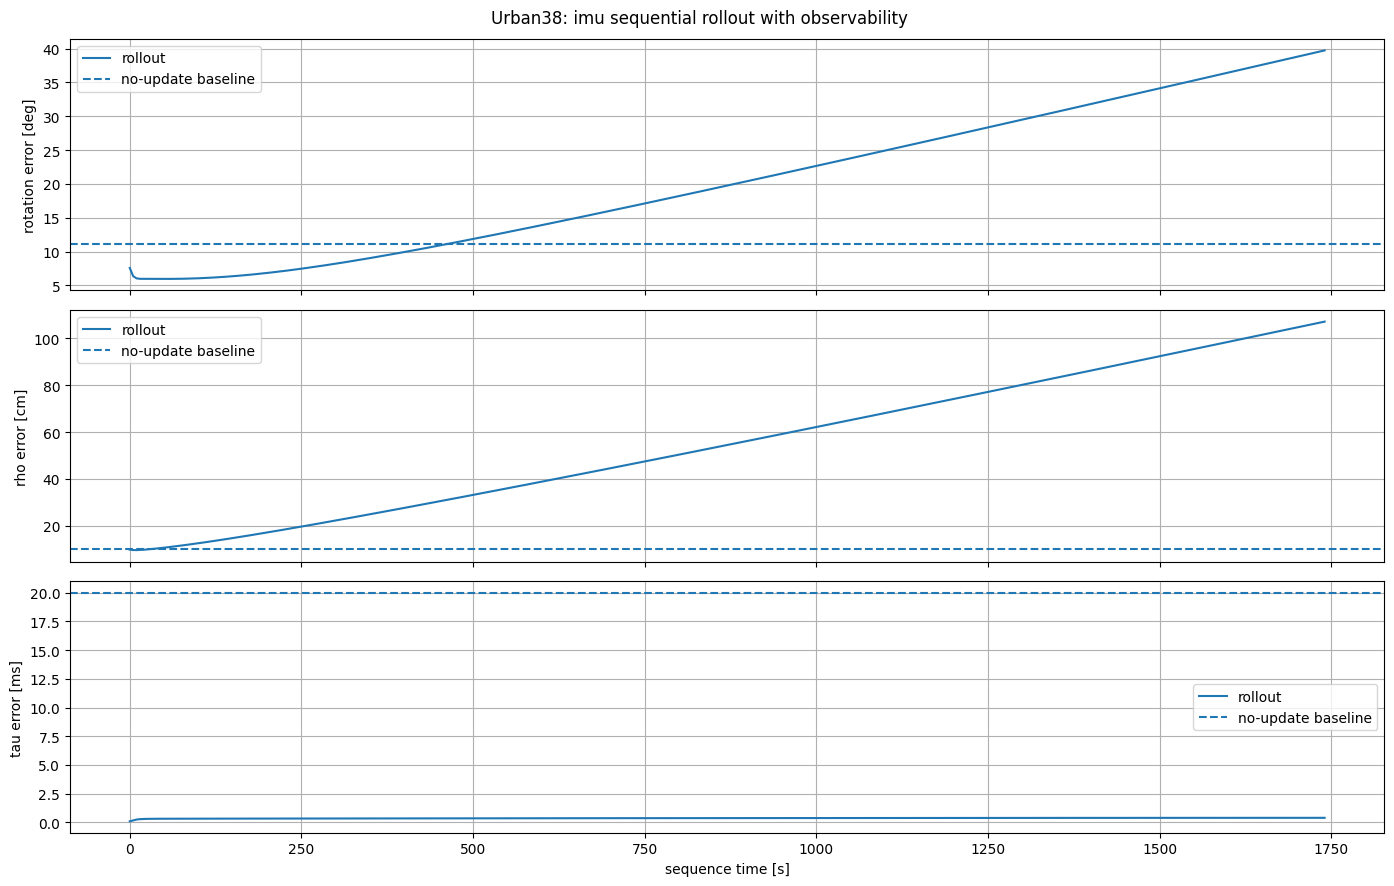

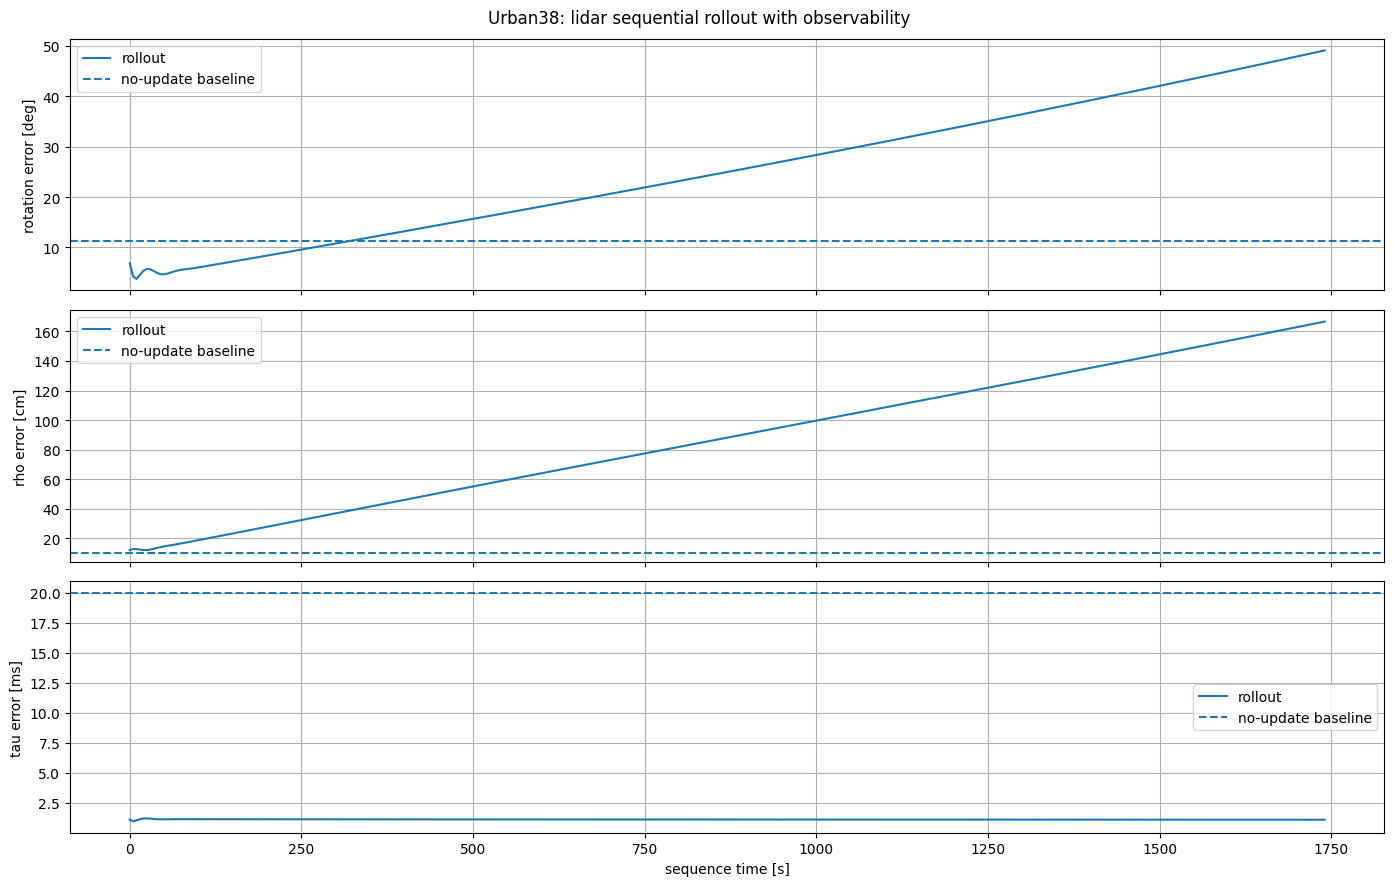

In [16]:
def plot_rollout_error_norms(history, calibration_key):
    result = history[calibration_key]
    error_xi = result["error_after_xi"]
    error_tau = result["error_after_tau"][:, 0]
    times_s = np.arange(len(error_xi)) * windowing_config.window_stride_s
    rotation_error_deg = np.rad2deg(np.linalg.norm(error_xi[:, :3], axis=1))
    translation_error_cm = 100.0 * np.linalg.norm(error_xi[:, 3:], axis=1)
    time_offset_error_ms = 1000.0 * np.abs(error_tau)
    initial_rotation_deg = np.rad2deg(np.linalg.norm(INITIAL_DELTA_XI[calibration_key][:3]))
    initial_translation_cm = 100.0 * np.linalg.norm(INITIAL_DELTA_XI[calibration_key][3:])
    initial_tau_ms = 1000.0 * abs(INITIAL_DELTA_TAU_S[calibration_key])

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    axes[0].plot(times_s, rotation_error_deg, label="rollout")
    axes[0].axhline(initial_rotation_deg, linestyle="--", label="no-update baseline")
    axes[0].set_ylabel("rotation error [deg]")
    axes[0].grid(True)
    axes[0].legend()
    axes[1].plot(times_s, translation_error_cm, label="rollout")
    axes[1].axhline(initial_translation_cm, linestyle="--", label="no-update baseline")
    axes[1].set_ylabel("rho error [cm]")
    axes[1].grid(True)
    axes[1].legend()
    axes[2].plot(times_s, time_offset_error_ms, label="rollout")
    axes[2].axhline(initial_tau_ms, linestyle="--", label="no-update baseline")
    axes[2].set_ylabel("tau error [ms]")
    axes[2].set_xlabel("sequence time [s]")
    axes[2].grid(True)
    axes[2].legend()
    fig.suptitle(f"{SEQUENCE_NAME}: {calibration_key} sequential rollout with observability")
    fig.tight_layout()
    plt.show()

plot_rollout_error_norms(rollout_history, "imu")
plot_rollout_error_norms(rollout_history, "lidar")

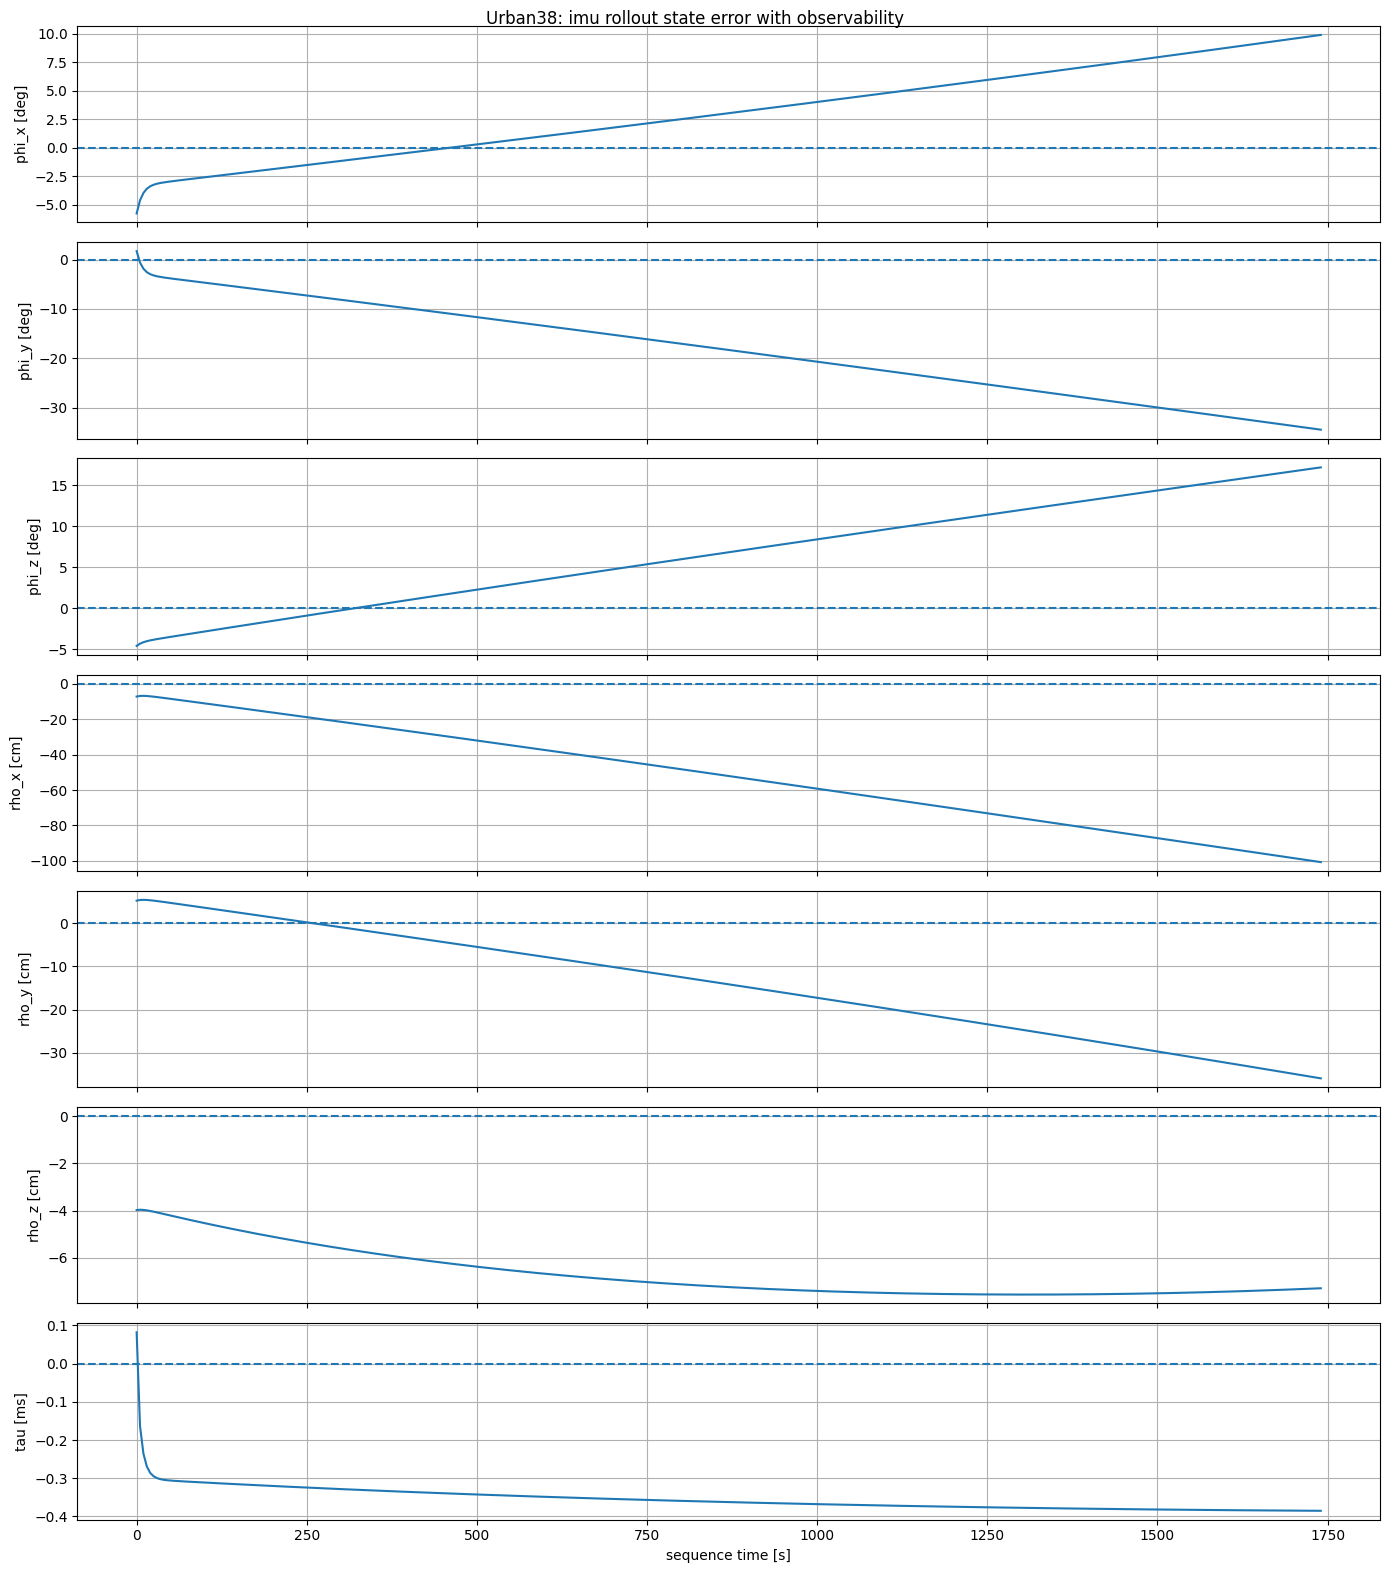

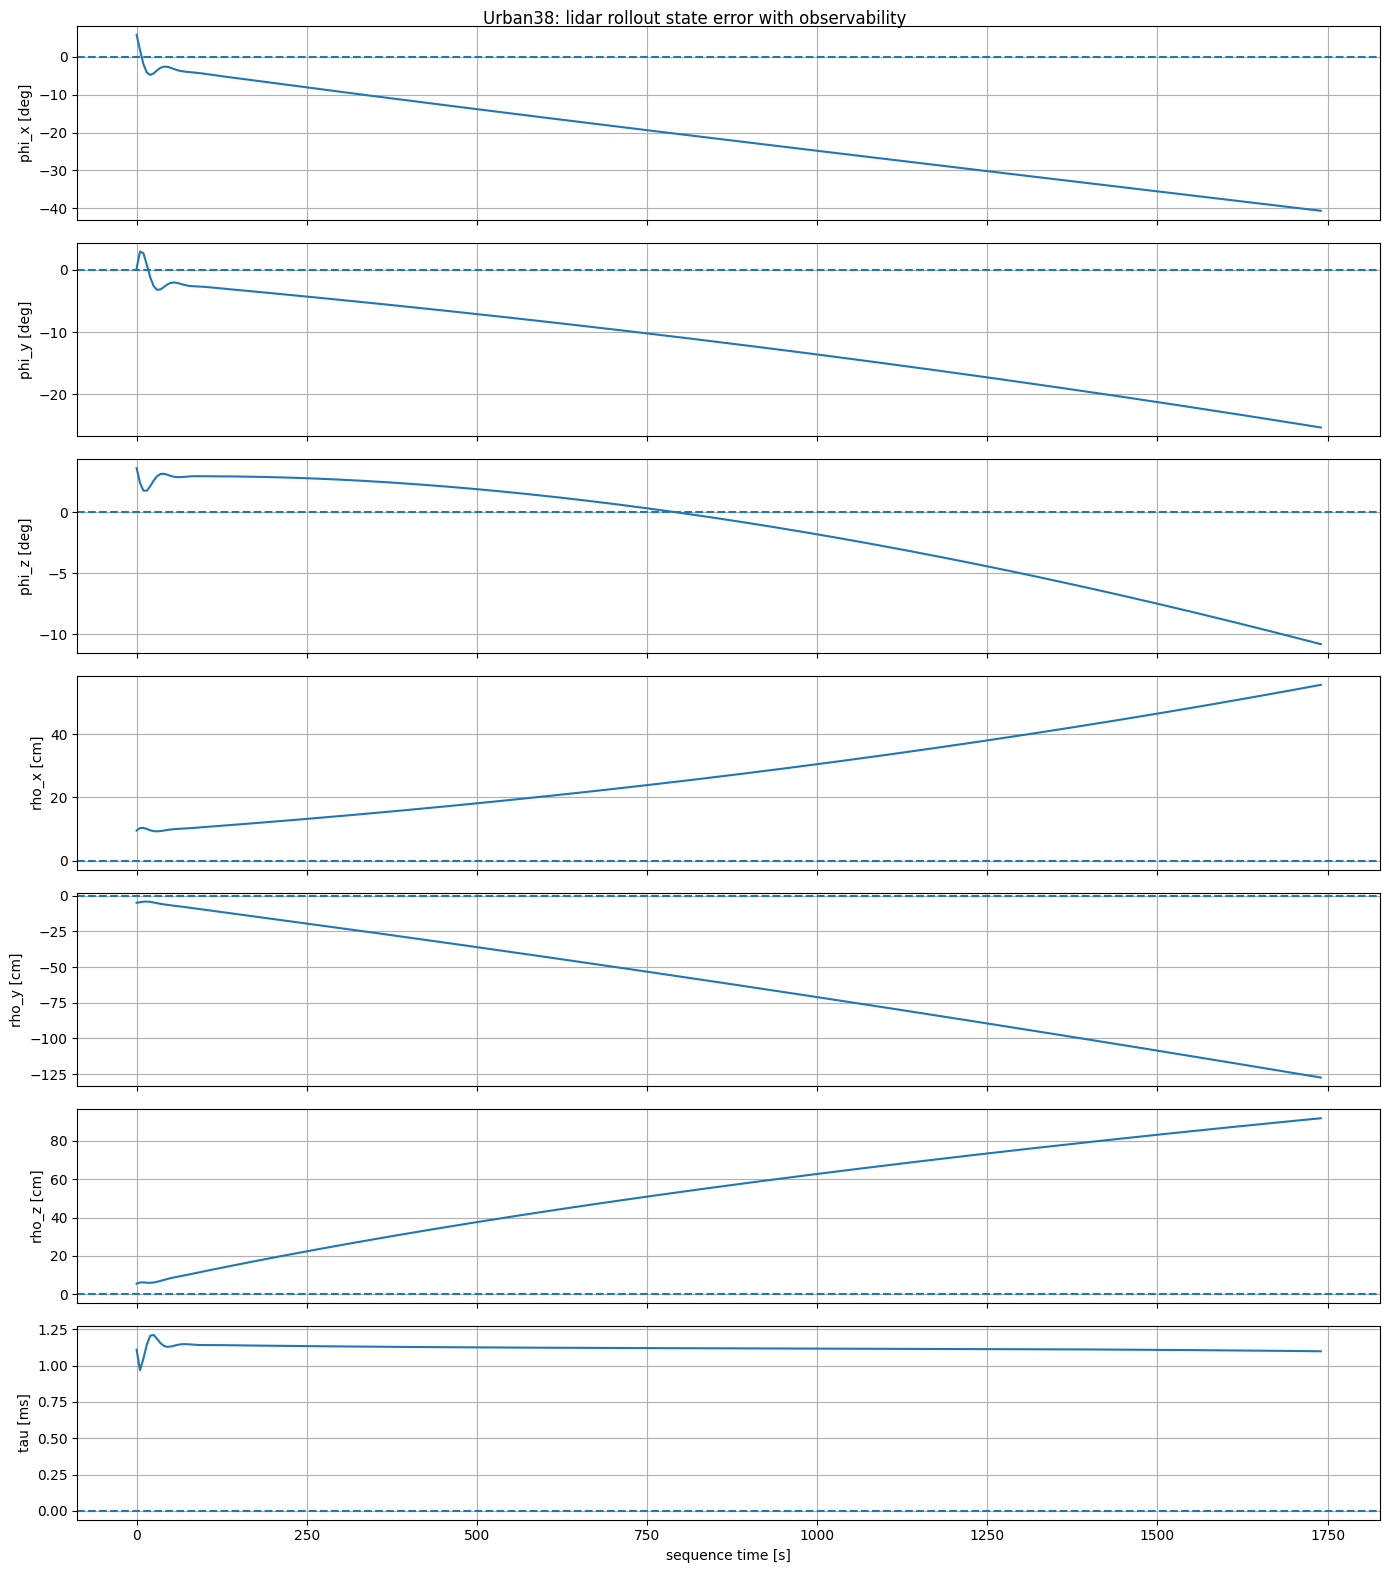

In [17]:
COMPONENT_NAMES = ("phi_x", "phi_y", "phi_z", "rho_x", "rho_y", "rho_z")

def plot_rollout_components(history, calibration_key):
    result = history[calibration_key]
    error_xi = result["error_after_xi"]
    error_tau = result["error_after_tau"][:, 0]
    times_s = np.arange(len(error_xi)) * windowing_config.window_stride_s
    fig, axes = plt.subplots(7, 1, figsize=(14, 16), sharex=True)

    for component_index in range(3):
        axes[component_index].plot(times_s, np.rad2deg(error_xi[:, component_index]))
        axes[component_index].axhline(0.0, linestyle="--")
        axes[component_index].set_ylabel(f"{COMPONENT_NAMES[component_index]} [deg]")
        axes[component_index].grid(True)

    for component_index in range(3, 6):
        axes[component_index].plot(times_s, 100.0 * error_xi[:, component_index])
        axes[component_index].axhline(0.0, linestyle="--")
        axes[component_index].set_ylabel(f"{COMPONENT_NAMES[component_index]} [cm]")
        axes[component_index].grid(True)

    axes[-1].plot(times_s, 1000.0 * error_tau)
    axes[-1].axhline(0.0, linestyle="--")
    axes[-1].set_ylabel("tau [ms]")
    axes[-1].set_xlabel("sequence time [s]")
    axes[-1].grid(True)
    fig.suptitle(f"{SEQUENCE_NAME}: {calibration_key} rollout state error with observability")
    fig.tight_layout()
    plt.show()

plot_rollout_components(rollout_history, "imu")
plot_rollout_components(rollout_history, "lidar")

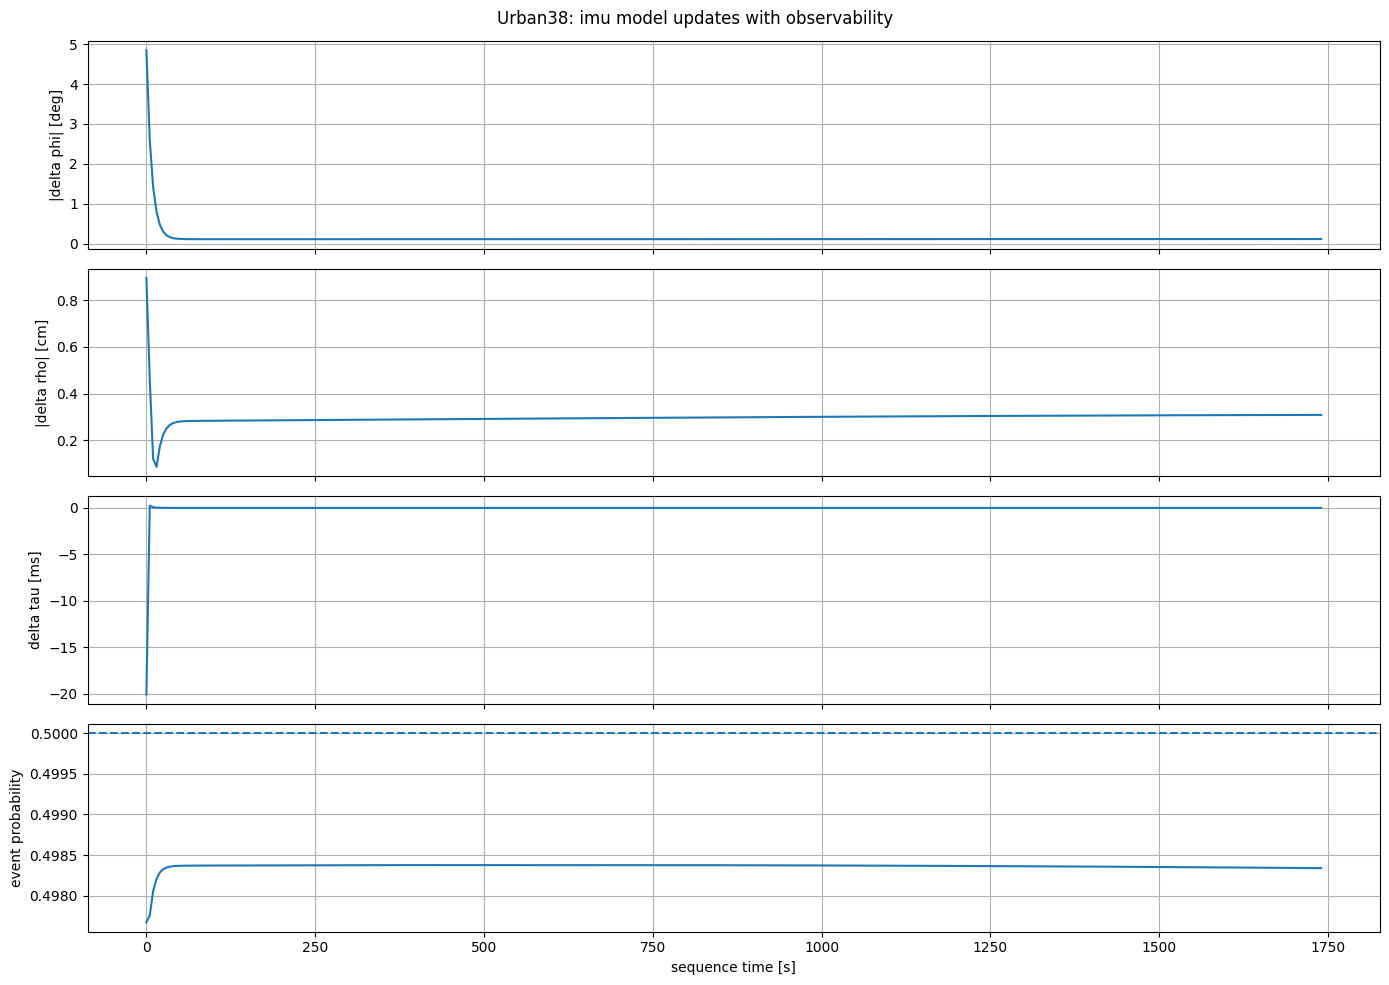

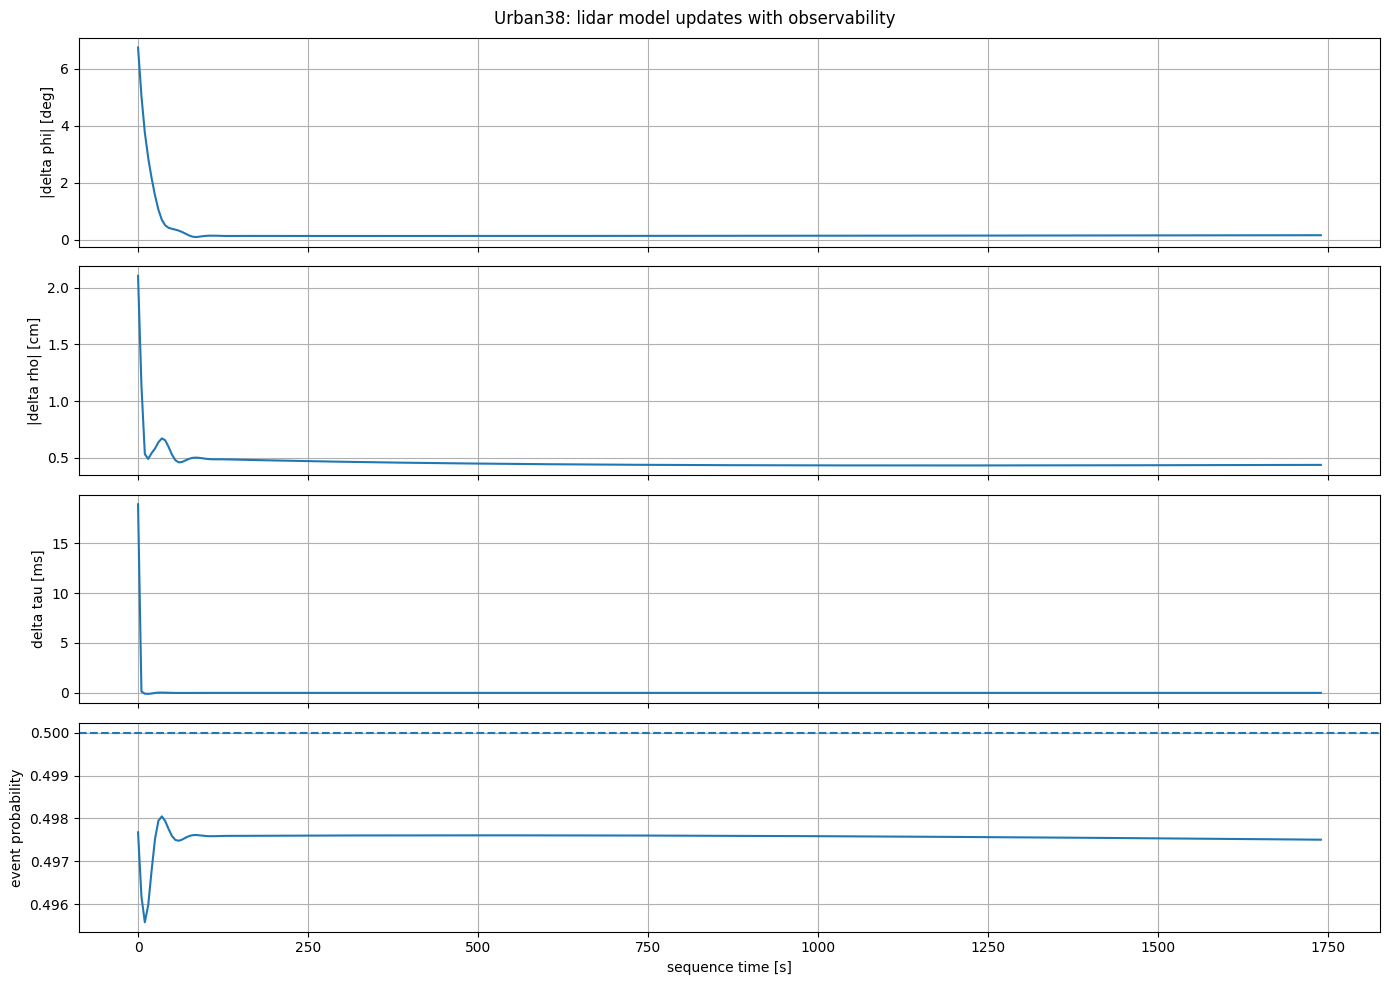

In [18]:
def plot_predicted_updates(history, calibration_key):
    result = history[calibration_key]
    delta_xi = result["predicted_delta_xi"]
    delta_tau = result["predicted_delta_tau"][:, 0]
    event_probability = result["event_probability"][:, 0]
    times_s = np.arange(len(delta_xi)) * windowing_config.window_stride_s
    rotation_update_deg = np.rad2deg(np.linalg.norm(delta_xi[:, :3], axis=1))
    translation_update_cm = 100.0 * np.linalg.norm(delta_xi[:, 3:], axis=1)

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    axes[0].plot(times_s, rotation_update_deg)
    axes[0].set_ylabel("|delta phi| [deg]")
    axes[1].plot(times_s, translation_update_cm)
    axes[1].set_ylabel("|delta rho| [cm]")
    axes[2].plot(times_s, 1000.0 * delta_tau)
    axes[2].set_ylabel("delta tau [ms]")
    axes[3].plot(times_s, event_probability)
    axes[3].axhline(0.5, linestyle="--")
    axes[3].set_ylabel("event probability")
    axes[3].set_xlabel("sequence time [s]")

    for axis in axes:
        axis.grid(True)

    fig.suptitle(f"{SEQUENCE_NAME}: {calibration_key} model updates with observability")
    fig.tight_layout()
    plt.show()

plot_predicted_updates(rollout_history, "imu")
plot_predicted_updates(rollout_history, "lidar")

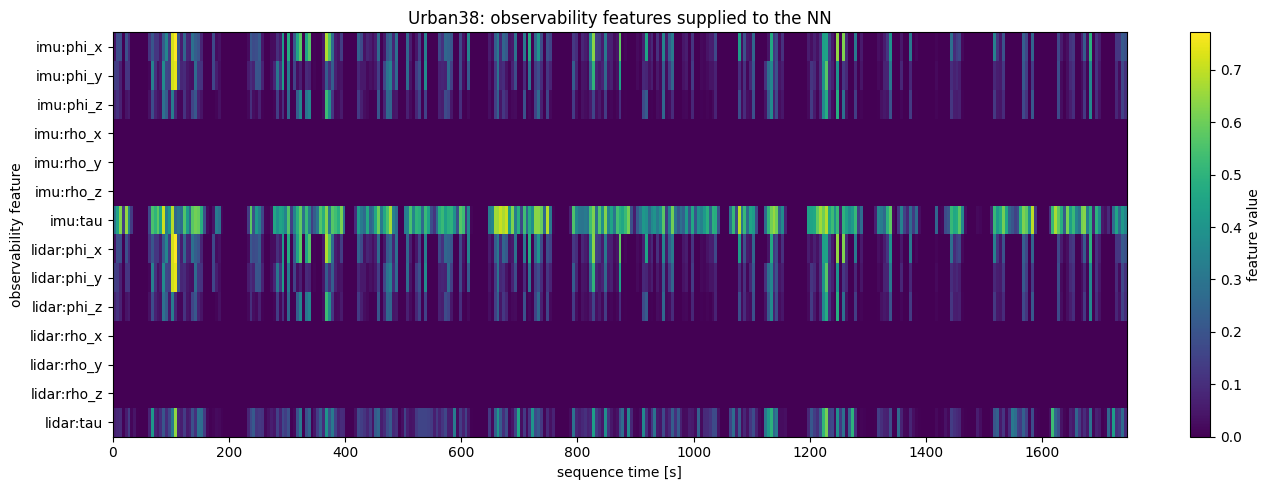

Per-feature minimum: [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 4.10782519e-15]
Per-feature mean: [0.09917323 0.07007289 0.05242814 0.         0.         0.
 0.30891937 0.09917326 0.07007307 0.05242816 0.         0.
 0.         0.10744593]
Per-feature maximum: [0.77155759 0.74328901 0.52874005 0.         0.         0.
 0.71133129 0.77157386 0.74332973 0.52873757 0.         0.
 0.         0.64726712]


In [19]:
##################################################
# Observability features seen by the network
##################################################

times_s = np.arange(observability_feature_history.shape[0]) * windowing_config.window_stride_s

if OBSERVABILITY_MODE == "crlb_tanh" and observability_feature_history.shape[1] == calibration_layout.total_dimension:
    observability_feature_names = [f"{block.calibration_key}:{parameter_name}" for block in calibration_layout.blocks for parameter_name in block.parameter_names]
else:
    observability_feature_names = [f"feature_{index}" for index in range(observability_feature_history.shape[1])]

fig, axis = plt.subplots(figsize=(14, max(5, 0.32 * observability_feature_history.shape[1])))
image = axis.imshow(observability_feature_history.T, aspect="auto", interpolation="nearest", extent=[times_s[0], times_s[-1] + windowing_config.window_stride_s, observability_feature_history.shape[1] - 0.5, -0.5])
axis.set_yticks(np.arange(observability_feature_history.shape[1]))
axis.set_yticklabels(observability_feature_names)
axis.set_xlabel("sequence time [s]")
axis.set_ylabel("observability feature")
axis.set_title(f"{SEQUENCE_NAME}: observability features supplied to the NN")
fig.colorbar(image, ax=axis, label="feature value")
fig.tight_layout()
plt.show()

print("Per-feature minimum:", np.min(observability_feature_history, axis=0))
print("Per-feature mean:", np.mean(observability_feature_history, axis=0))
print("Per-feature maximum:", np.max(observability_feature_history, axis=0))